In [29]:
from ultralytics import YOLO
from PIL import Image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import torch
import cv2
import os
import sys
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt" # path to model weight (pre model loaded from: https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt)
model_cfg = "../sam2/configs/sam2.1/sam2.1_hiera_t.yaml" #  model config
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda") # load model
predictor = SAM2ImagePredictor(sam2_model)
predictor.model.load_state_dict(torch.load("../fined_tuned_1.pt"))

<All keys matched successfully>


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/377.png: 576x640 1 target, 58.2ms
Speed: 37.9ms preprocess, 58.2ms inference, 45.6ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/377.png: 576x640 (no detections), 26.8ms
Speed: 2.7ms preprocess, 26.8ms inference, 2.3ms postprocess per image at shape (1, 3, 576, 640)


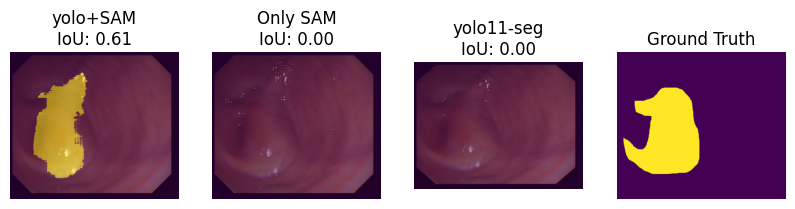

[np.float64(0.6059391264801496), np.float64(0.0010786655366361044), np.float64(0.0)]


In [ ]:
import numpy as np
from ultralytics import YOLO
yolo_seg = YOLO('../../yolo/models/yolo11n-seg-trained-on-seg-mixed-cli-col-ETIS.pt')
yolo = YOLO('../../yolo/models/yolo11n-trained-on-mixed-cli-col-ETIS.pt')

def calculate_iou(mask, ground_truth):
    if mask.shape != ground_truth.shape:
        mask_resized = cv2.resize(mask.astype(np.uint8), (ground_truth.shape[1], ground_truth.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        mask_resized = mask.astype(np.uint8)
    intersection = np.logical_and(mask_resized, ground_truth).sum()
    union = np.logical_or(mask_resized, ground_truth).sum()
    return intersection / union if union != 0 else 0

def eval_one_pic(dataset_dir, picture, label):
    plt.figure(figsize=(10, 40))
    picture = f'{dataset_dir}/images/test/{picture}'
    label = cv2.imread(f'{dataset_dir}/masks/test/{label}', cv2.IMREAD_GRAYSCALE)
    label = (label > 127).astype(np.uint8)
    def yolo_sam(picture):
        img = cv2.imread(picture)
        results = yolo.predict(picture)
        boxes = results[0].boxes.xyxy[0].cpu().numpy()
        predictor.set_image(img)  
        masks, _, _ = predictor.predict(
            box = boxes,
            multimask_output=True,
        )
        return masks[0]
    def sam_only(picture):
        img = cv2.imread(picture)
        predictor.set_image(img)
        masks, _, _ = predictor.predict(
            multimask_output=True,
        )
        return masks[0]
    IoUs = []
    masks = yolo_sam(picture)
    plt.subplot(1, 4, 1)
    plt.imshow(Image.open(picture))
    plt.imshow(masks, alpha=0.5)
    iou = calculate_iou(masks, label)
    IoUs.append(iou)
    plt.title(f"yolo+SAM\nIoU: {iou:.2f}")
    plt.axis('off')
    plt.subplot(1, 4, 2)
    masks = sam_only(picture)
    plt.imshow(Image.open(picture))
    plt.imshow(masks, alpha=0.5)
    iou = calculate_iou(masks, label)
    IoUs.append(iou)
    plt.title(f"Only SAM\nIoU: {iou:.2f}")
    plt.axis('off')
    plt.subplot(1, 4, 3)
    masks = yolo_seg.predict(picture)[0].masks
    masks = masks.data[0].cpu().numpy() if masks else np.zeros([480, 640])
    masks = (masks > 0).astype(np.uint8)
    img_org = Image.open(picture)
    mask_shape = masks.shape
    img_org_resized = img_org.resize((mask_shape[1], mask_shape[0]), Image.BILINEAR)
    plt.imshow(img_org_resized)
    plt.imshow(masks, alpha=0.5)
    iou = calculate_iou(masks, label)
    IoUs.append(iou)
    plt.title(f"yolo11-seg\nIoU: {iou:.2f}")
    plt.axis('off')
    plt.subplot(1, 4, 4)
    plt.imshow(label)
    plt.title("Ground Truth")
    plt.axis('off')
    plt.show()
    return IoUs

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/101.png: 576x640 1 target, 12.0ms
Speed: 2.6ms preprocess, 12.0ms inference, 2.3ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/101.png: 576x640 1 target, 13.9ms
Speed: 2.5ms preprocess, 13.9ms inference, 11.0ms postprocess per image at shape (1, 3, 576, 640)


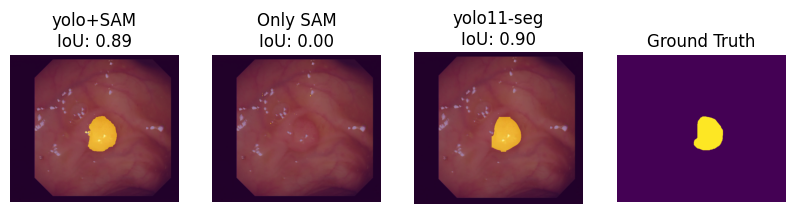


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/108.png: 512x640 1 target, 54.0ms
Speed: 3.2ms preprocess, 54.0ms inference, 2.5ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/108.png: 512x640 1 target, 32.9ms
Speed: 3.3ms preprocess, 32.9ms inference, 3.7ms postprocess per image at shape (1, 3, 512, 640)


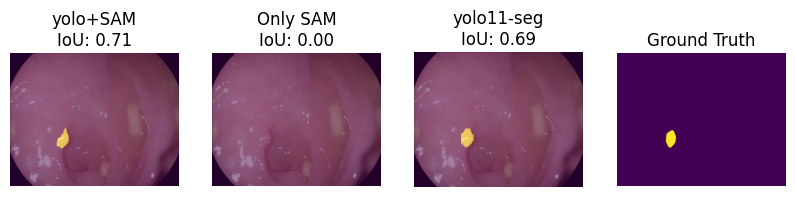


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/109.png: 480x640 1 target, 40.9ms
Speed: 2.2ms preprocess, 40.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/109.png: 480x640 1 target, 28.3ms
Speed: 2.1ms preprocess, 28.3ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)


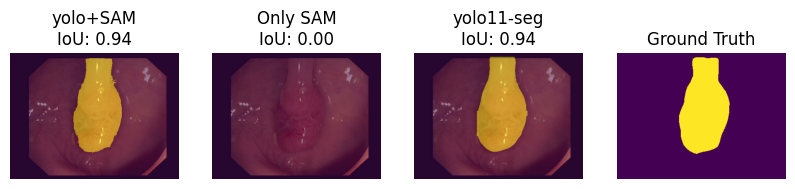


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/111.png: 480x640 1 target, 10.8ms
Speed: 1.9ms preprocess, 10.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/111.png: 480x640 1 target, 16.2ms
Speed: 1.9ms preprocess, 16.2ms inference, 4.3ms postprocess per image at shape (1, 3, 480, 640)


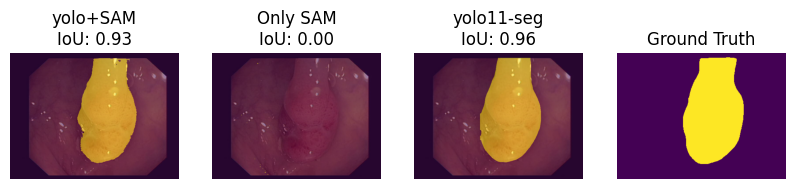


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/119.png: 480x640 1 target, 13.5ms
Speed: 2.3ms preprocess, 13.5ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/119.png: 480x640 1 target, 17.5ms
Speed: 3.1ms preprocess, 17.5ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)


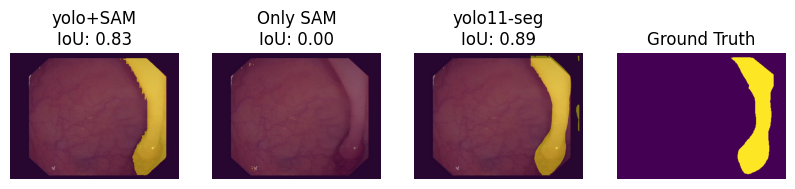


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/120.png: 576x640 1 target, 24.4ms
Speed: 3.1ms preprocess, 24.4ms inference, 3.5ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/120.png: 576x640 1 target, 17.0ms
Speed: 3.0ms preprocess, 17.0ms inference, 3.1ms postprocess per image at shape (1, 3, 576, 640)


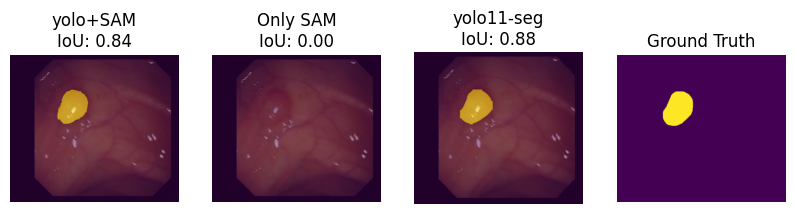


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/122.png: 480x640 1 target, 24.0ms
Speed: 1.9ms preprocess, 24.0ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/122.png: 480x640 1 target, 15.1ms
Speed: 2.5ms preprocess, 15.1ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)


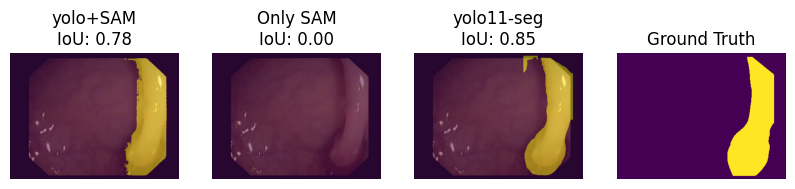


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/123.png: 576x640 1 target, 17.1ms
Speed: 2.8ms preprocess, 17.1ms inference, 3.8ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/123.png: 576x640 1 target, 24.2ms
Speed: 2.9ms preprocess, 24.2ms inference, 3.1ms postprocess per image at shape (1, 3, 576, 640)


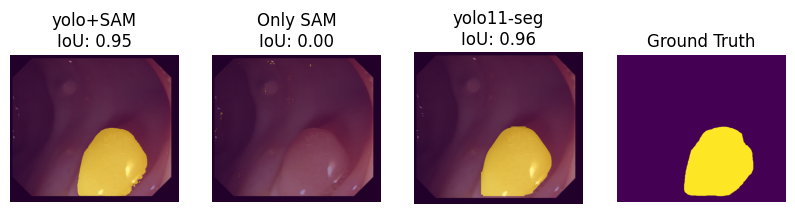


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/125.png: 576x640 1 target, 19.4ms
Speed: 3.2ms preprocess, 19.4ms inference, 2.4ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/125.png: 576x640 1 target, 13.3ms
Speed: 2.4ms preprocess, 13.3ms inference, 5.3ms postprocess per image at shape (1, 3, 576, 640)


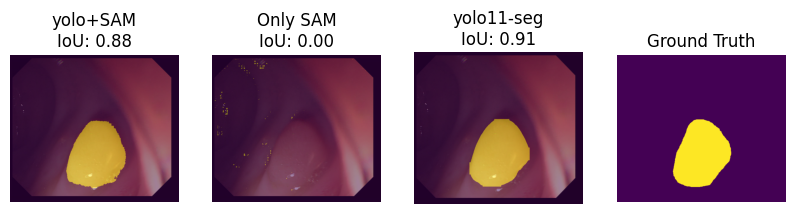


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/127.png: 480x640 1 target, 13.8ms
Speed: 2.2ms preprocess, 13.8ms inference, 5.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/127.png: 480x640 1 target, 18.5ms
Speed: 2.0ms preprocess, 18.5ms inference, 5.9ms postprocess per image at shape (1, 3, 480, 640)


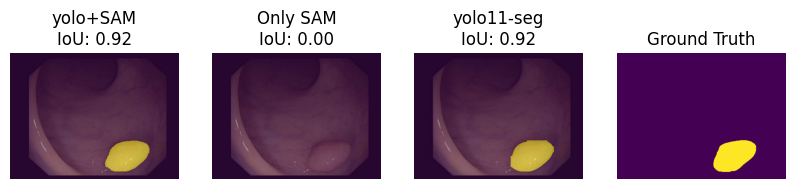


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/136.png: 512x640 1 target, 14.0ms
Speed: 2.8ms preprocess, 14.0ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/136.png: 512x640 1 target, 16.3ms
Speed: 2.4ms preprocess, 16.3ms inference, 4.9ms postprocess per image at shape (1, 3, 512, 640)


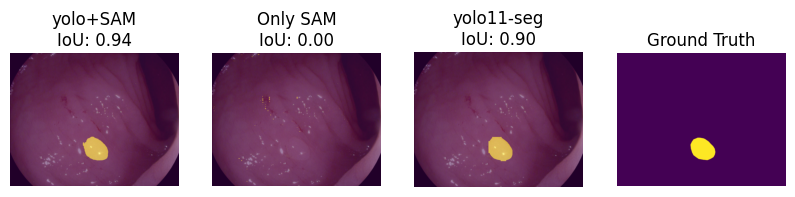


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/14.png: 480x640 1 target, 15.9ms
Speed: 2.0ms preprocess, 15.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/14.png: 480x640 1 target, 19.5ms
Speed: 2.0ms preprocess, 19.5ms inference, 4.5ms postprocess per image at shape (1, 3, 480, 640)


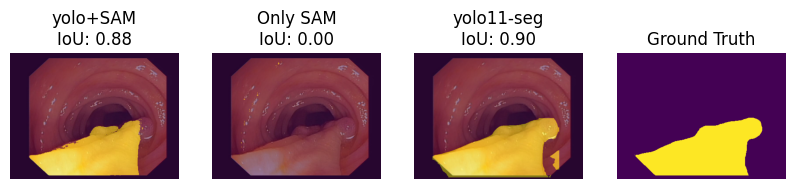


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/141.png: 480x640 1 target, 21.5ms
Speed: 2.2ms preprocess, 21.5ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/141.png: 480x640 1 target, 16.8ms
Speed: 2.1ms preprocess, 16.8ms inference, 4.8ms postprocess per image at shape (1, 3, 480, 640)


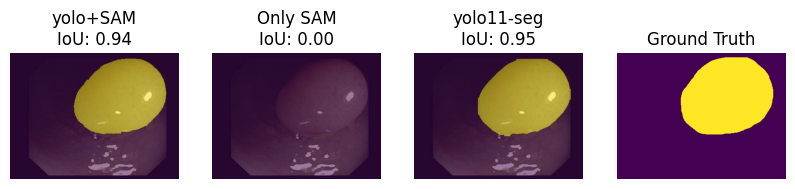


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/142.png: 576x640 1 target, 17.3ms
Speed: 3.5ms preprocess, 17.3ms inference, 1.9ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/142.png: 576x640 1 target, 16.4ms
Speed: 2.5ms preprocess, 16.4ms inference, 2.9ms postprocess per image at shape (1, 3, 576, 640)


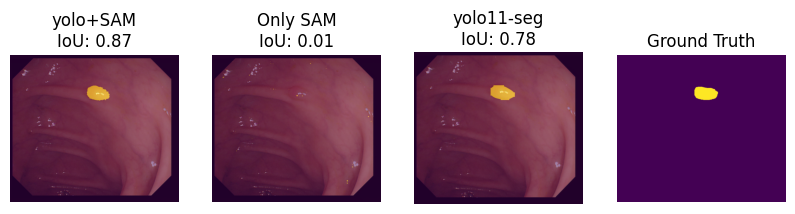


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/143.png: 512x640 3 targets, 13.0ms
Speed: 2.6ms preprocess, 13.0ms inference, 262.3ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/143.png: 512x640 3 targets, 13.6ms
Speed: 3.5ms preprocess, 13.6ms inference, 12.7ms postprocess per image at shape (1, 3, 512, 640)


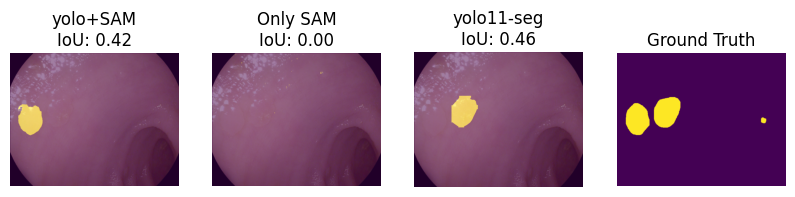


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/148.png: 512x640 1 target, 18.0ms
Speed: 3.7ms preprocess, 18.0ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/148.png: 512x640 1 target, 14.5ms
Speed: 2.7ms preprocess, 14.5ms inference, 4.4ms postprocess per image at shape (1, 3, 512, 640)


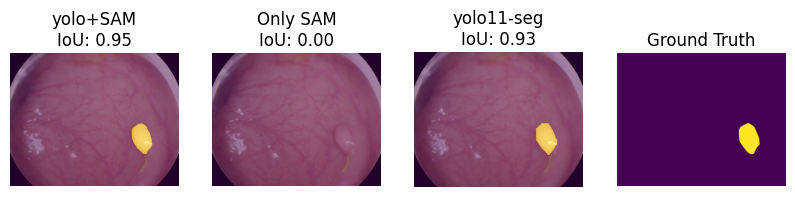


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/149.png: 576x640 1 target, 14.2ms
Speed: 3.5ms preprocess, 14.2ms inference, 4.8ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/149.png: 576x640 1 target, 14.2ms
Speed: 3.0ms preprocess, 14.2ms inference, 2.9ms postprocess per image at shape (1, 3, 576, 640)


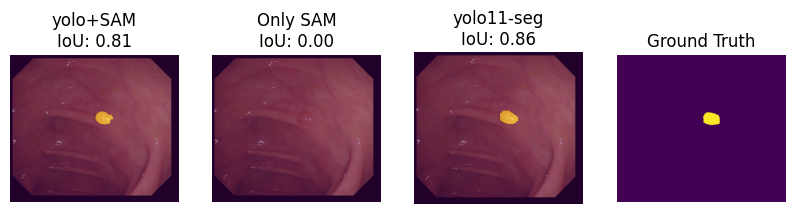


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/158.png: 512x640 1 target, 26.1ms
Speed: 3.4ms preprocess, 26.1ms inference, 4.4ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/158.png: 512x640 1 target, 18.7ms
Speed: 33.7ms preprocess, 18.7ms inference, 3.0ms postprocess per image at shape (1, 3, 512, 640)


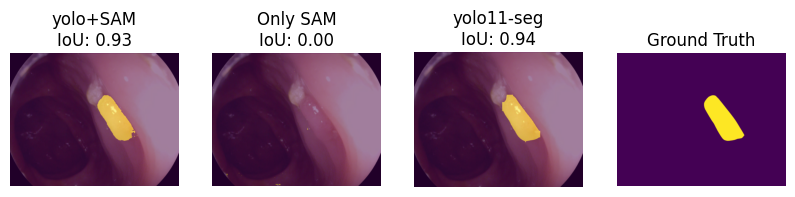


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/160.png: 480x640 1 target, 16.8ms
Speed: 2.0ms preprocess, 16.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/160.png: 480x640 1 target, 17.4ms
Speed: 24.5ms preprocess, 17.4ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)


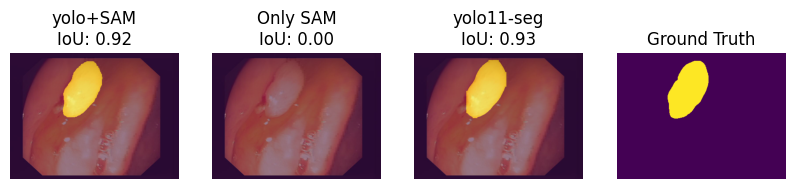


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/164.png: 512x640 1 target, 13.4ms
Speed: 2.6ms preprocess, 13.4ms inference, 2.0ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/164.png: 512x640 1 target, 15.8ms
Speed: 2.9ms preprocess, 15.8ms inference, 6.3ms postprocess per image at shape (1, 3, 512, 640)


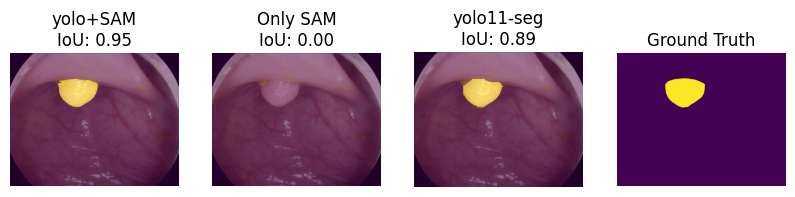


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/165.png: 512x640 1 target, 12.9ms
Speed: 2.8ms preprocess, 12.9ms inference, 2.1ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/165.png: 512x640 1 target, 15.0ms
Speed: 2.6ms preprocess, 15.0ms inference, 4.7ms postprocess per image at shape (1, 3, 512, 640)


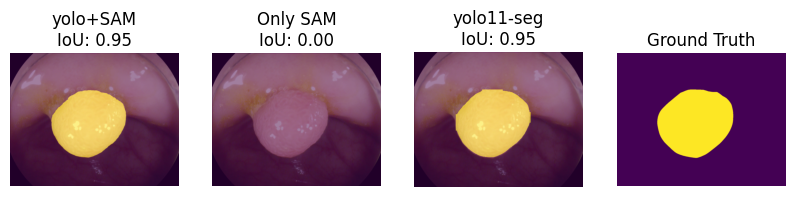


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/167.png: 576x640 1 target, 24.9ms
Speed: 2.7ms preprocess, 24.9ms inference, 4.6ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/167.png: 576x640 1 target, 15.1ms
Speed: 2.7ms preprocess, 15.1ms inference, 4.7ms postprocess per image at shape (1, 3, 576, 640)


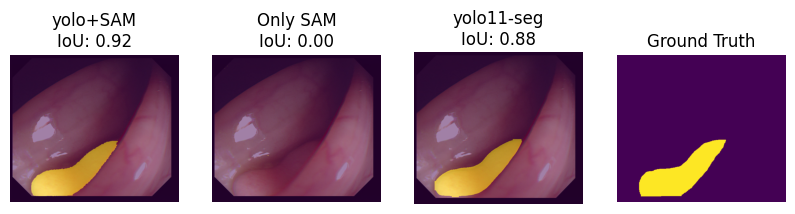


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/179.png: 480x640 1 target, 12.4ms
Speed: 1.8ms preprocess, 12.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/179.png: 480x640 1 target, 20.0ms
Speed: 2.0ms preprocess, 20.0ms inference, 5.8ms postprocess per image at shape (1, 3, 480, 640)


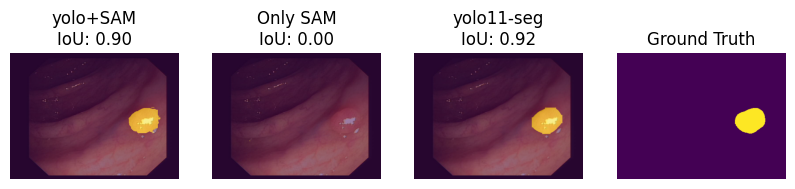


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/18.png: 480x640 1 target, 22.8ms
Speed: 2.5ms preprocess, 22.8ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/18.png: 480x640 1 target, 15.0ms
Speed: 2.3ms preprocess, 15.0ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)


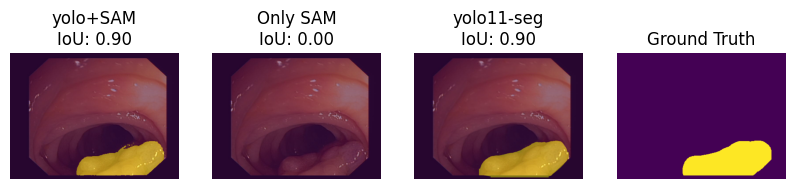


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/180.png: 480x640 1 target, 15.5ms
Speed: 2.0ms preprocess, 15.5ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/180.png: 480x640 1 target, 17.5ms
Speed: 1.8ms preprocess, 17.5ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)


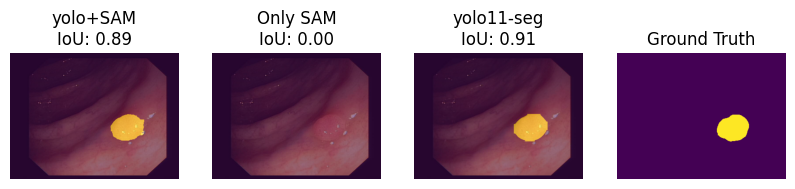


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/187.png: 480x640 1 target, 11.6ms
Speed: 1.9ms preprocess, 11.6ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/187.png: 480x640 1 target, 12.5ms
Speed: 2.2ms preprocess, 12.5ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


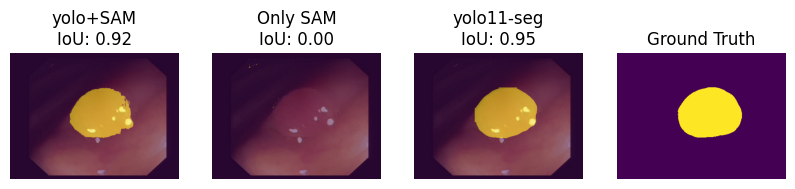


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/189.png: 512x640 1 target, 18.3ms
Speed: 3.1ms preprocess, 18.3ms inference, 2.1ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/189.png: 512x640 2 targets, 18.4ms
Speed: 3.3ms preprocess, 18.4ms inference, 4.9ms postprocess per image at shape (1, 3, 512, 640)


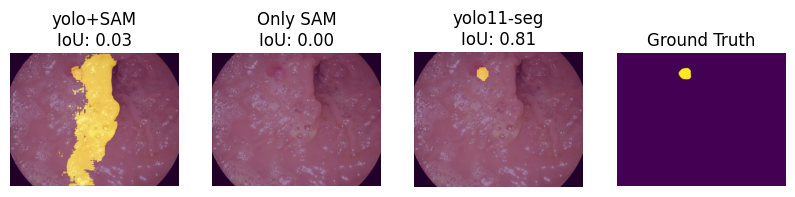


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/190.png: 512x640 1 target, 24.6ms
Speed: 5.2ms preprocess, 24.6ms inference, 3.1ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/190.png: 512x640 1 target, 18.1ms
Speed: 3.0ms preprocess, 18.1ms inference, 5.3ms postprocess per image at shape (1, 3, 512, 640)


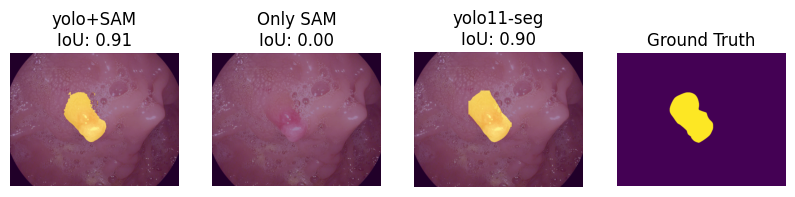


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/191.png: 576x640 1 target, 29.0ms
Speed: 2.5ms preprocess, 29.0ms inference, 3.8ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/191.png: 576x640 1 target, 17.6ms
Speed: 2.4ms preprocess, 17.6ms inference, 4.0ms postprocess per image at shape (1, 3, 576, 640)


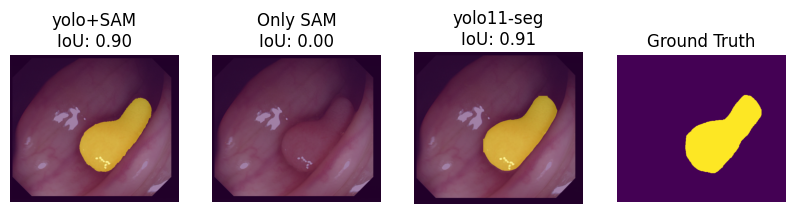


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/195.png: 480x640 1 target, 13.4ms
Speed: 1.8ms preprocess, 13.4ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/195.png: 480x640 1 target, 27.2ms
Speed: 1.9ms preprocess, 27.2ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)


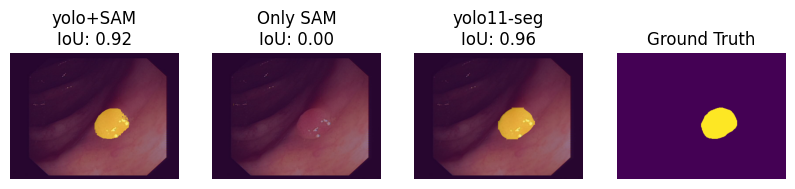


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/198.png: 576x640 1 target, 17.4ms
Speed: 2.8ms preprocess, 17.4ms inference, 1.8ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/198.png: 576x640 1 target, 19.0ms
Speed: 2.7ms preprocess, 19.0ms inference, 3.3ms postprocess per image at shape (1, 3, 576, 640)


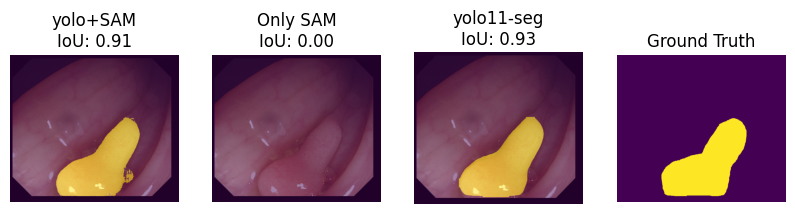


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/211.png: 512x640 1 target, 12.7ms
Speed: 2.9ms preprocess, 12.7ms inference, 2.6ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/211.png: 512x640 1 target, 14.1ms
Speed: 2.8ms preprocess, 14.1ms inference, 3.0ms postprocess per image at shape (1, 3, 512, 640)


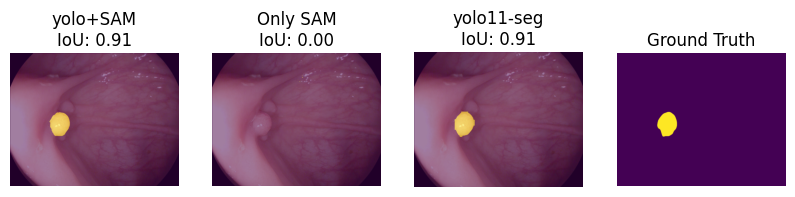


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/214.png: 512x640 1 target, 14.7ms
Speed: 2.9ms preprocess, 14.7ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/214.png: 512x640 1 target, 12.8ms
Speed: 2.5ms preprocess, 12.8ms inference, 3.1ms postprocess per image at shape (1, 3, 512, 640)


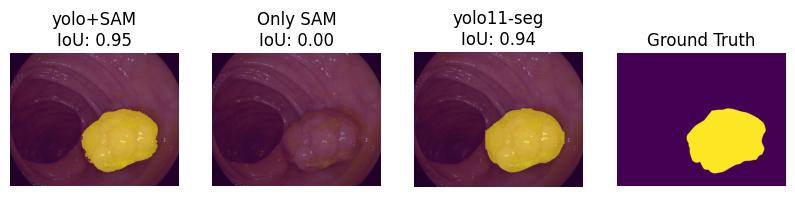


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/215.png: 512x640 1 target, 16.5ms
Speed: 3.3ms preprocess, 16.5ms inference, 3.9ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/215.png: 512x640 1 target, 13.6ms
Speed: 2.9ms preprocess, 13.6ms inference, 5.4ms postprocess per image at shape (1, 3, 512, 640)


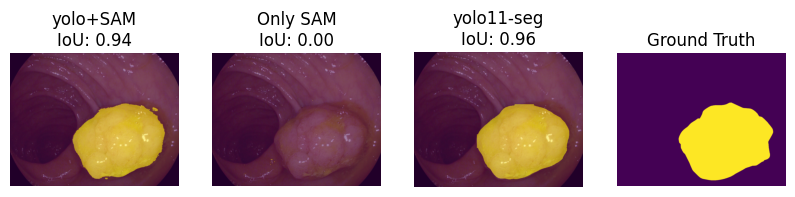


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/219.png: 480x640 1 target, 25.2ms
Speed: 1.9ms preprocess, 25.2ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/219.png: 480x640 1 target, 27.7ms
Speed: 2.5ms preprocess, 27.7ms inference, 5.7ms postprocess per image at shape (1, 3, 480, 640)


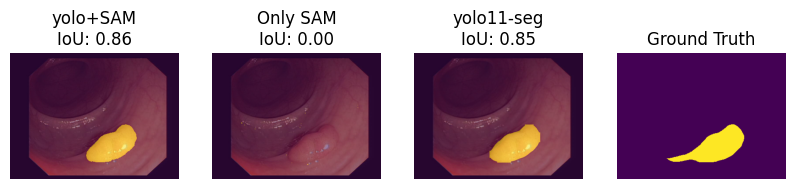


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/221.png: 512x640 1 target, 24.4ms
Speed: 3.5ms preprocess, 24.4ms inference, 4.3ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/221.png: 512x640 1 target, 17.2ms
Speed: 2.9ms preprocess, 17.2ms inference, 3.7ms postprocess per image at shape (1, 3, 512, 640)


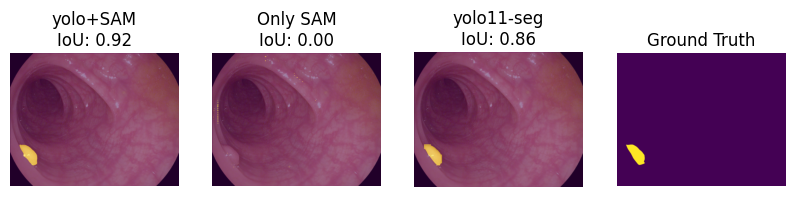


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/225.png: 512x640 1 target, 12.8ms
Speed: 3.7ms preprocess, 12.8ms inference, 2.3ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/225.png: 512x640 1 target, 13.2ms
Speed: 4.1ms preprocess, 13.2ms inference, 3.0ms postprocess per image at shape (1, 3, 512, 640)


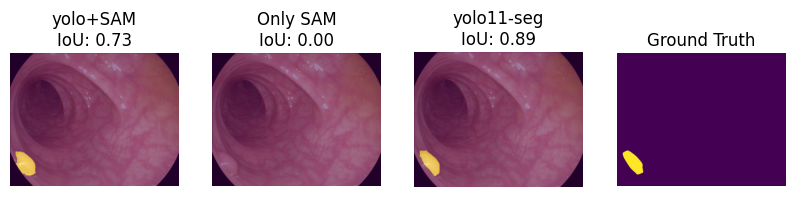


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/231.png: 480x640 1 target, 16.4ms
Speed: 1.9ms preprocess, 16.4ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/231.png: 480x640 1 target, 17.6ms
Speed: 2.1ms preprocess, 17.6ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)


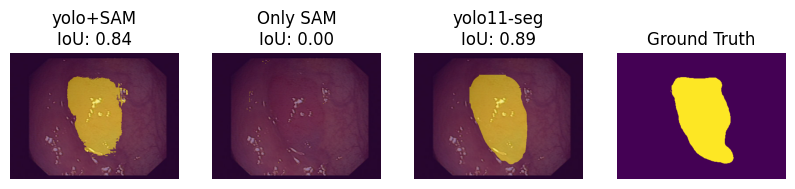


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/234.png: 512x640 1 target, 28.4ms
Speed: 3.4ms preprocess, 28.4ms inference, 2.7ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/234.png: 512x640 1 target, 15.4ms
Speed: 2.7ms preprocess, 15.4ms inference, 4.2ms postprocess per image at shape (1, 3, 512, 640)


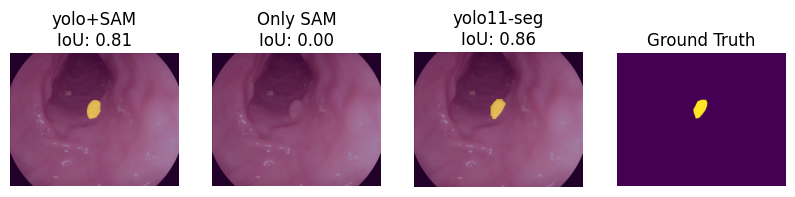


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/241.png: 576x640 1 target, 14.8ms
Speed: 2.4ms preprocess, 14.8ms inference, 3.0ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/241.png: 576x640 1 target, 13.0ms
Speed: 2.5ms preprocess, 13.0ms inference, 5.4ms postprocess per image at shape (1, 3, 576, 640)


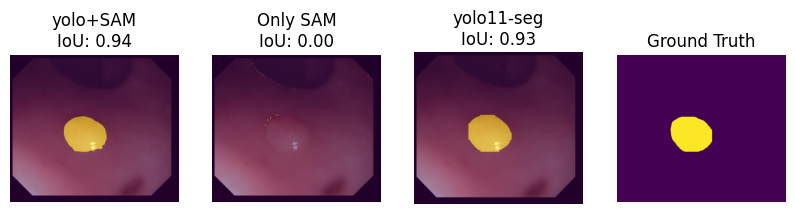


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/246.png: 576x640 1 target, 18.8ms
Speed: 3.5ms preprocess, 18.8ms inference, 2.1ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/246.png: 576x640 1 target, 15.6ms
Speed: 2.9ms preprocess, 15.6ms inference, 5.8ms postprocess per image at shape (1, 3, 576, 640)


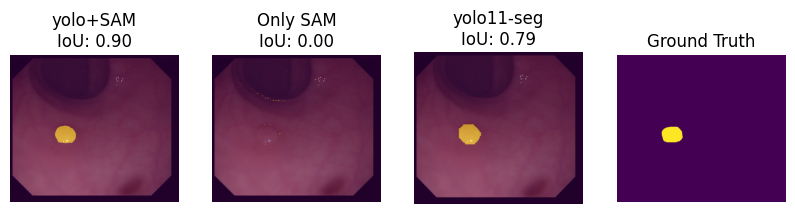


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/248.png: 480x640 1 target, 16.4ms
Speed: 2.0ms preprocess, 16.4ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/248.png: 480x640 1 target, 14.5ms
Speed: 1.9ms preprocess, 14.5ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)


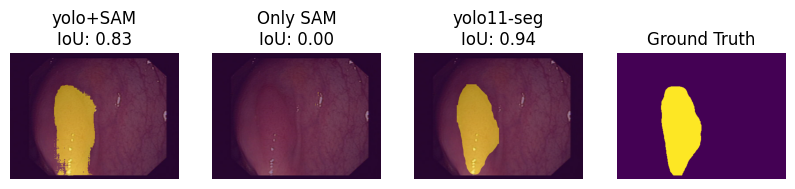


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/250.png: 512x640 1 target, 27.6ms
Speed: 2.8ms preprocess, 27.6ms inference, 4.2ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/250.png: 512x640 1 target, 14.5ms
Speed: 3.0ms preprocess, 14.5ms inference, 4.1ms postprocess per image at shape (1, 3, 512, 640)


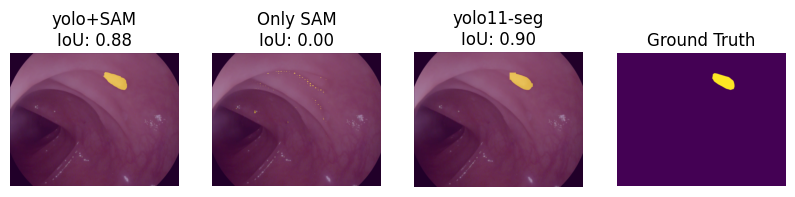


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/252.png: 576x640 1 target, 15.9ms
Speed: 2.6ms preprocess, 15.9ms inference, 1.8ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/252.png: 576x640 1 target, 15.4ms
Speed: 2.2ms preprocess, 15.4ms inference, 3.3ms postprocess per image at shape (1, 3, 576, 640)


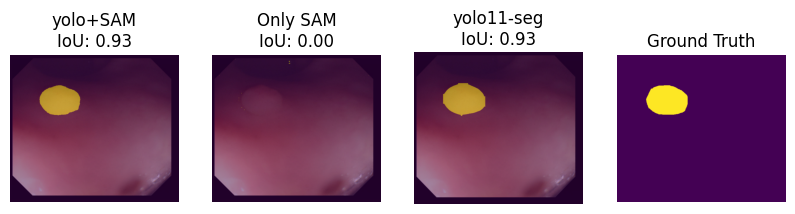


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/254.png: 480x640 1 target, 12.4ms
Speed: 2.0ms preprocess, 12.4ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/254.png: 480x640 1 target, 15.8ms
Speed: 1.9ms preprocess, 15.8ms inference, 3.6ms postprocess per image at shape (1, 3, 480, 640)


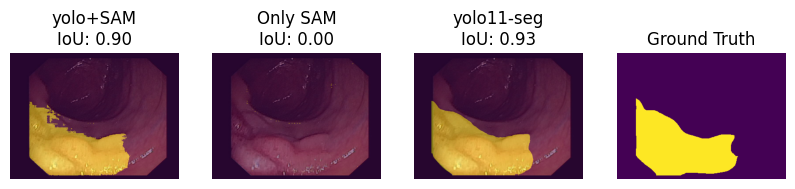


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/255.png: 512x640 1 target, 19.0ms
Speed: 2.8ms preprocess, 19.0ms inference, 3.0ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/255.png: 512x640 1 target, 15.2ms
Speed: 2.8ms preprocess, 15.2ms inference, 2.9ms postprocess per image at shape (1, 3, 512, 640)


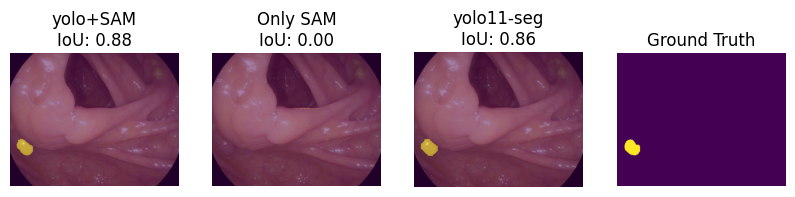


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/263.png: 576x640 1 target, 12.8ms
Speed: 3.1ms preprocess, 12.8ms inference, 5.0ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/263.png: 576x640 1 target, 15.6ms
Speed: 3.3ms preprocess, 15.6ms inference, 5.8ms postprocess per image at shape (1, 3, 576, 640)


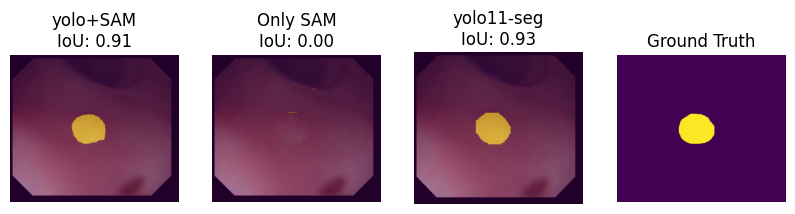


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/264.png: 480x640 1 target, 11.8ms
Speed: 2.5ms preprocess, 11.8ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/264.png: 480x640 1 target, 15.1ms
Speed: 2.0ms preprocess, 15.1ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)


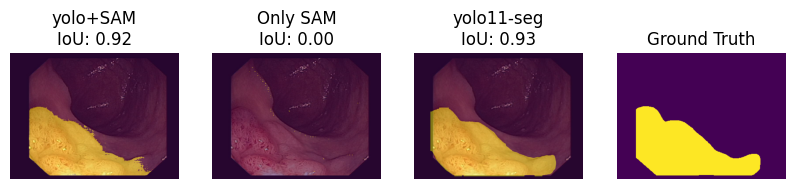


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/271.png: 576x640 1 target, 18.1ms
Speed: 3.1ms preprocess, 18.1ms inference, 1.9ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/271.png: 576x640 1 target, 18.9ms
Speed: 2.5ms preprocess, 18.9ms inference, 3.0ms postprocess per image at shape (1, 3, 576, 640)


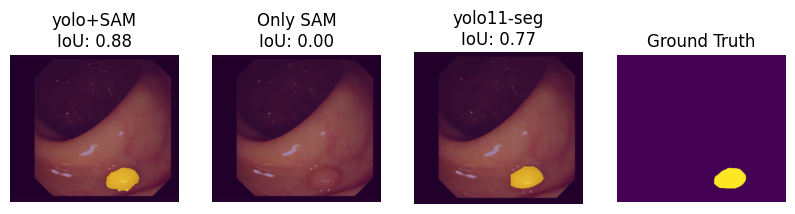


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/277.png: 480x640 1 target, 16.8ms
Speed: 2.0ms preprocess, 16.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/277.png: 480x640 1 target, 15.8ms
Speed: 2.0ms preprocess, 15.8ms inference, 3.0ms postprocess per image at shape (1, 3, 480, 640)


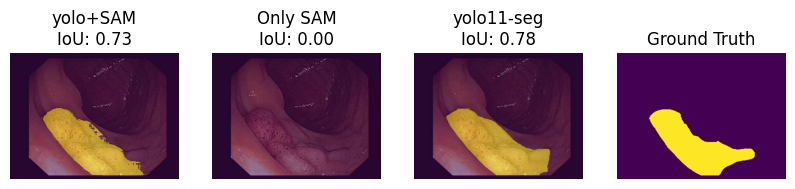


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/280.png: 512x640 1 target, 13.0ms
Speed: 3.0ms preprocess, 13.0ms inference, 2.0ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/280.png: 512x640 1 target, 13.8ms
Speed: 3.1ms preprocess, 13.8ms inference, 2.9ms postprocess per image at shape (1, 3, 512, 640)


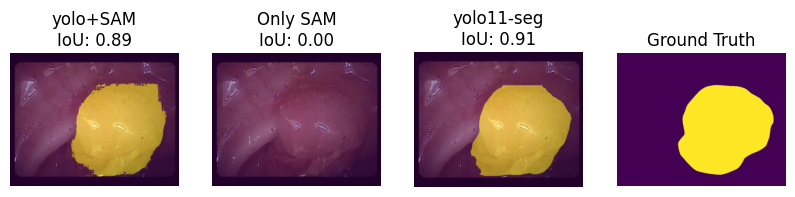


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/284.png: 512x640 1 target, 14.8ms
Speed: 3.8ms preprocess, 14.8ms inference, 3.7ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/284.png: 512x640 1 target, 13.6ms
Speed: 2.8ms preprocess, 13.6ms inference, 4.2ms postprocess per image at shape (1, 3, 512, 640)


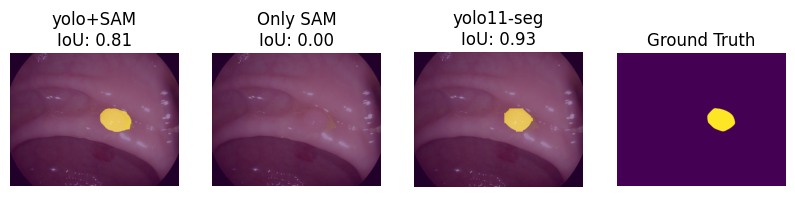


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/285.png: 576x640 1 target, 16.1ms
Speed: 2.4ms preprocess, 16.1ms inference, 2.4ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/285.png: 576x640 1 target, 16.4ms
Speed: 2.5ms preprocess, 16.4ms inference, 3.2ms postprocess per image at shape (1, 3, 576, 640)


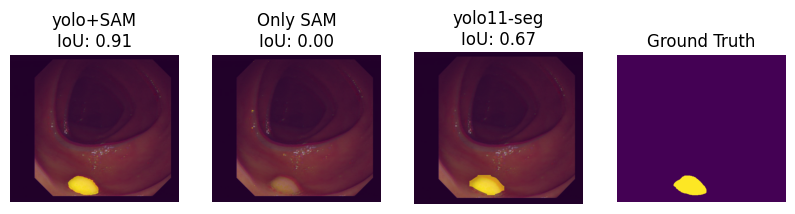


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/286.png: 512x640 1 target, 18.1ms
Speed: 3.7ms preprocess, 18.1ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/286.png: 512x640 1 target, 13.5ms
Speed: 2.7ms preprocess, 13.5ms inference, 3.1ms postprocess per image at shape (1, 3, 512, 640)


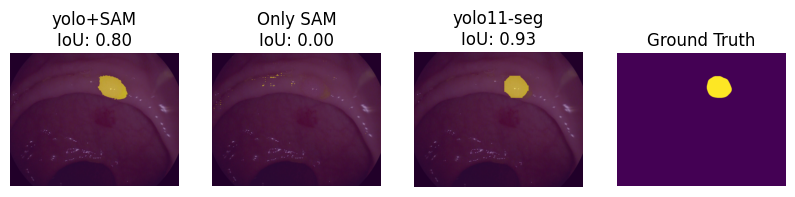


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/287.png: 576x640 1 target, 15.9ms
Speed: 2.7ms preprocess, 15.9ms inference, 5.0ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/287.png: 576x640 1 target, 18.8ms
Speed: 2.5ms preprocess, 18.8ms inference, 3.3ms postprocess per image at shape (1, 3, 576, 640)


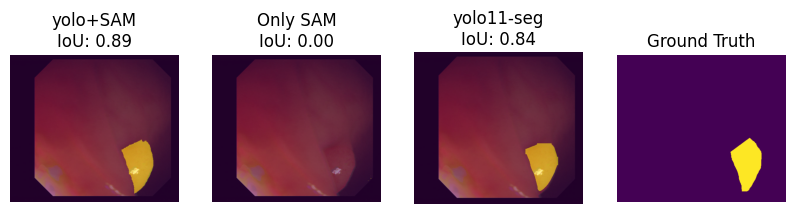


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/293.png: 576x640 1 target, 12.9ms
Speed: 3.1ms preprocess, 12.9ms inference, 3.6ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/293.png: 576x640 1 target, 18.1ms
Speed: 2.4ms preprocess, 18.1ms inference, 3.1ms postprocess per image at shape (1, 3, 576, 640)


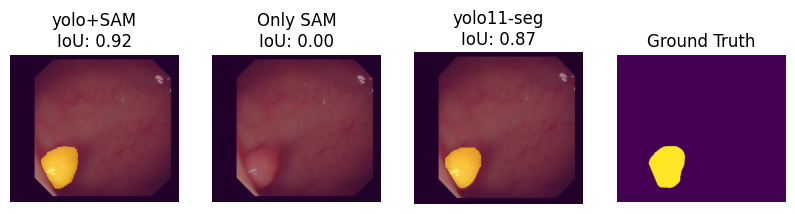


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/294.png: 480x640 1 target, 16.2ms
Speed: 1.9ms preprocess, 16.2ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/294.png: 480x640 1 target, 15.5ms
Speed: 2.0ms preprocess, 15.5ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


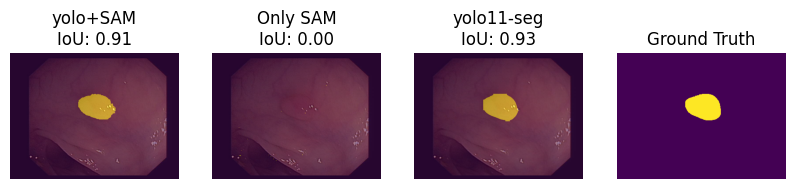


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/298.png: 480x640 1 target, 14.6ms
Speed: 2.2ms preprocess, 14.6ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/298.png: 480x640 1 target, 12.8ms
Speed: 1.9ms preprocess, 12.8ms inference, 5.5ms postprocess per image at shape (1, 3, 480, 640)


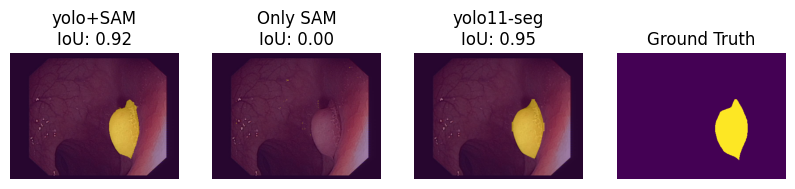


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/304.png: 480x640 1 target, 14.0ms
Speed: 1.8ms preprocess, 14.0ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/304.png: 480x640 1 target, 15.6ms
Speed: 1.9ms preprocess, 15.6ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 640)


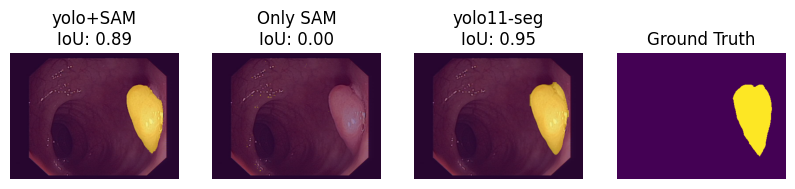


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/308.png: 480x640 1 target, 17.7ms
Speed: 2.5ms preprocess, 17.7ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/308.png: 480x640 1 target, 13.6ms
Speed: 2.0ms preprocess, 13.6ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)


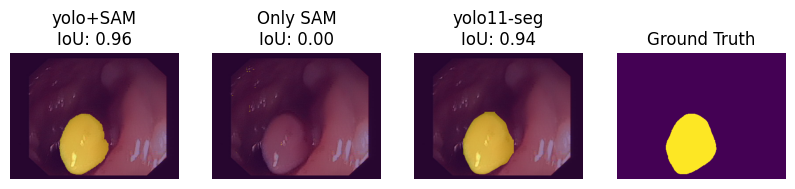


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/310.png: 576x640 1 target, 27.6ms
Speed: 2.9ms preprocess, 27.6ms inference, 2.7ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/310.png: 576x640 1 target, 18.3ms
Speed: 2.4ms preprocess, 18.3ms inference, 7.8ms postprocess per image at shape (1, 3, 576, 640)


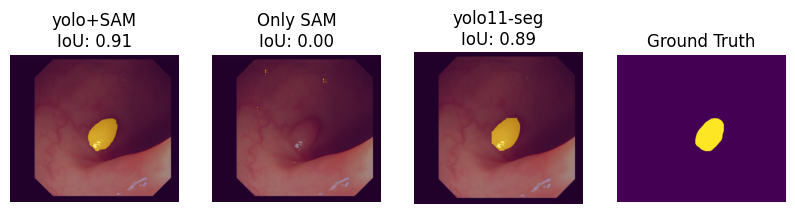


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/317.png: 576x640 1 target, 14.1ms
Speed: 2.6ms preprocess, 14.1ms inference, 2.5ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/317.png: 576x640 1 target, 14.6ms
Speed: 2.4ms preprocess, 14.6ms inference, 3.5ms postprocess per image at shape (1, 3, 576, 640)


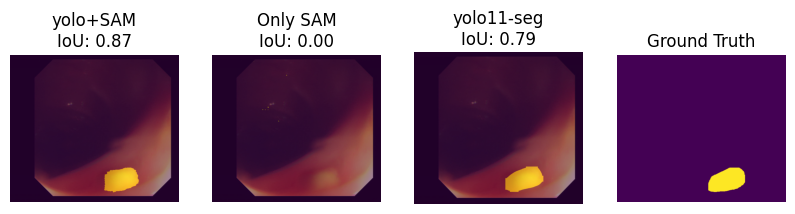


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/327.png: 576x640 1 target, 19.2ms
Speed: 2.6ms preprocess, 19.2ms inference, 6.2ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/327.png: 576x640 1 target, 14.2ms
Speed: 2.6ms preprocess, 14.2ms inference, 3.2ms postprocess per image at shape (1, 3, 576, 640)


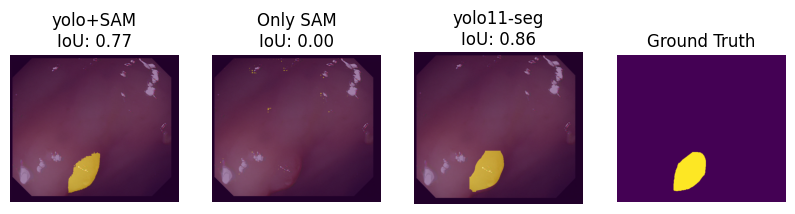


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/328.png: 480x640 1 target, 17.1ms
Speed: 2.0ms preprocess, 17.1ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/328.png: 480x640 1 target, 15.6ms
Speed: 1.9ms preprocess, 15.6ms inference, 3.6ms postprocess per image at shape (1, 3, 480, 640)


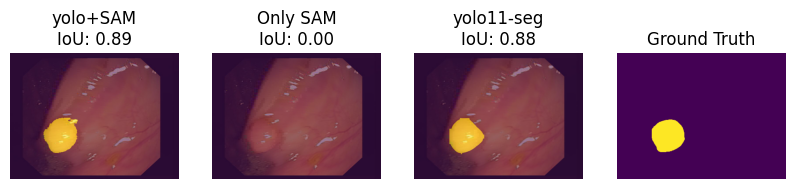


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/343.png: 576x640 1 target, 12.8ms
Speed: 2.4ms preprocess, 12.8ms inference, 2.3ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/343.png: 576x640 1 target, 20.3ms
Speed: 2.4ms preprocess, 20.3ms inference, 3.2ms postprocess per image at shape (1, 3, 576, 640)


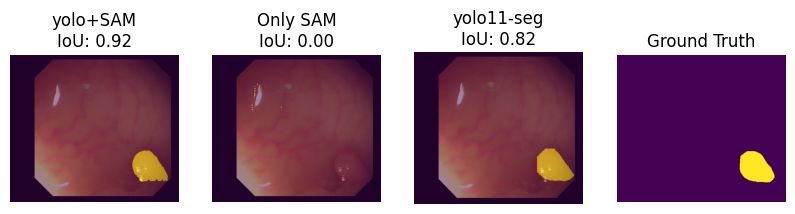


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/345.png: 480x640 1 target, 14.9ms
Speed: 2.5ms preprocess, 14.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/345.png: 480x640 1 target, 14.8ms
Speed: 1.8ms preprocess, 14.8ms inference, 6.1ms postprocess per image at shape (1, 3, 480, 640)


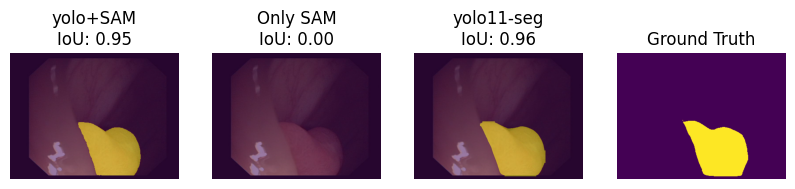


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/36.png: 480x640 1 target, 14.2ms
Speed: 2.2ms preprocess, 14.2ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/36.png: 480x640 1 target, 14.5ms
Speed: 2.5ms preprocess, 14.5ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)


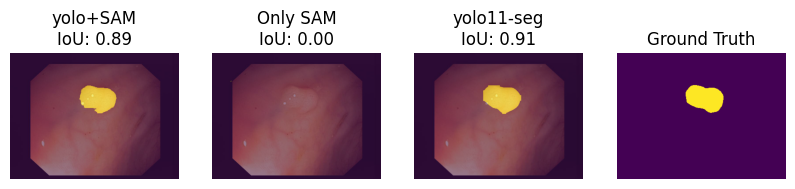


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/364.png: 480x640 1 target, 18.4ms
Speed: 2.0ms preprocess, 18.4ms inference, 4.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/364.png: 480x640 1 target, 15.1ms
Speed: 2.0ms preprocess, 15.1ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)


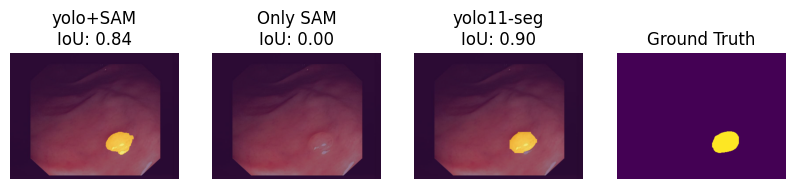


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/366.png: 480x640 1 target, 17.1ms
Speed: 2.9ms preprocess, 17.1ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/366.png: 480x640 1 target, 14.8ms
Speed: 2.0ms preprocess, 14.8ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)


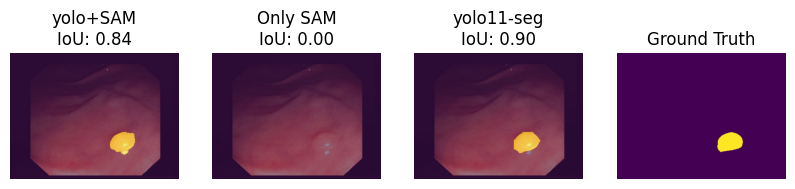


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/371.png: 576x640 2 targets, 15.4ms
Speed: 2.5ms preprocess, 15.4ms inference, 4.8ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/371.png: 576x640 1 target, 15.6ms
Speed: 2.6ms preprocess, 15.6ms inference, 7.1ms postprocess per image at shape (1, 3, 576, 640)


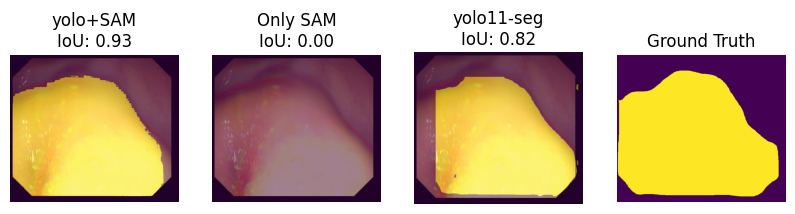


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/372.png: 576x640 1 target, 11.0ms
Speed: 3.2ms preprocess, 11.0ms inference, 1.8ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/372.png: 576x640 1 target, 13.0ms
Speed: 2.9ms preprocess, 13.0ms inference, 3.4ms postprocess per image at shape (1, 3, 576, 640)


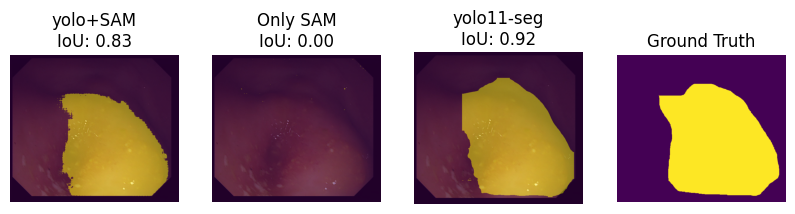


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/373.png: 576x640 1 target, 17.8ms
Speed: 2.4ms preprocess, 17.8ms inference, 7.1ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/373.png: 576x640 2 targets, 23.9ms
Speed: 2.7ms preprocess, 23.9ms inference, 4.7ms postprocess per image at shape (1, 3, 576, 640)


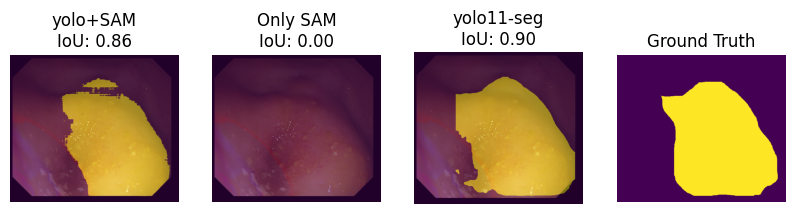


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/377.png: 576x640 1 target, 13.7ms
Speed: 2.7ms preprocess, 13.7ms inference, 5.4ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/377.png: 576x640 (no detections), 17.3ms
Speed: 2.9ms preprocess, 17.3ms inference, 0.8ms postprocess per image at shape (1, 3, 576, 640)


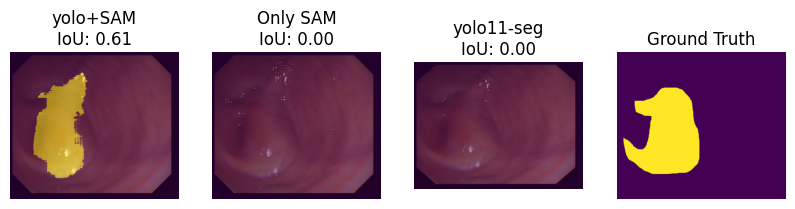


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/378.png: 576x640 1 target, 13.1ms
Speed: 3.3ms preprocess, 13.1ms inference, 8.4ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/378.png: 576x640 2 targets, 13.7ms
Speed: 2.8ms preprocess, 13.7ms inference, 6.0ms postprocess per image at shape (1, 3, 576, 640)


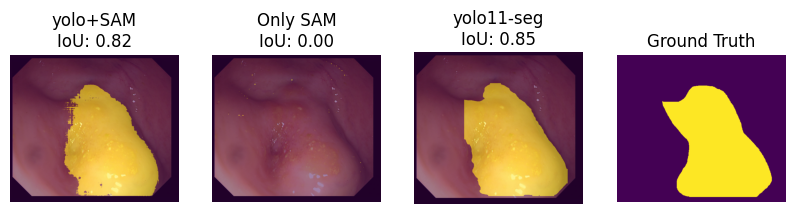


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/38.png: 480x640 1 target, 15.3ms
Speed: 3.0ms preprocess, 15.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/38.png: 480x640 1 target, 14.7ms
Speed: 2.0ms preprocess, 14.7ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)


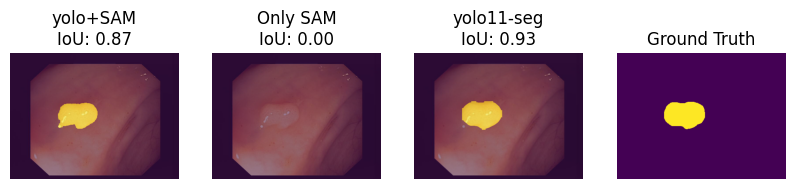


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/381.png: 576x640 1 target, 18.1ms
Speed: 2.9ms preprocess, 18.1ms inference, 2.7ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/381.png: 576x640 1 target, 19.9ms
Speed: 2.7ms preprocess, 19.9ms inference, 4.4ms postprocess per image at shape (1, 3, 576, 640)


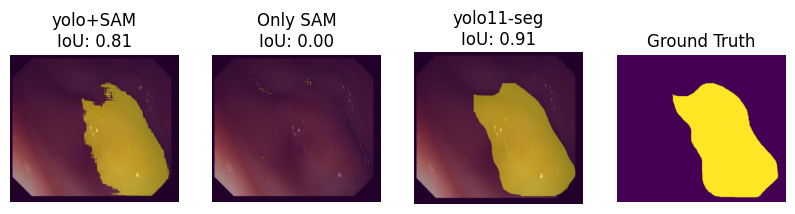


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/383.png: 480x640 1 target, 15.5ms
Speed: 2.0ms preprocess, 15.5ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/383.png: 480x640 1 target, 18.3ms
Speed: 2.0ms preprocess, 18.3ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


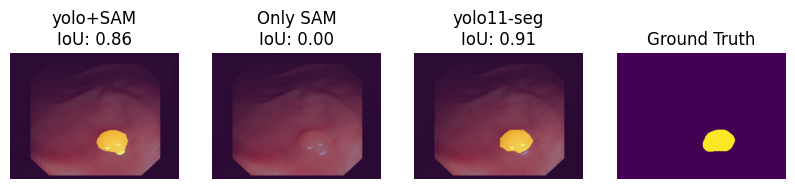


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/385.png: 480x640 1 target, 15.2ms
Speed: 2.2ms preprocess, 15.2ms inference, 4.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/385.png: 480x640 1 target, 16.0ms
Speed: 2.2ms preprocess, 16.0ms inference, 3.7ms postprocess per image at shape (1, 3, 480, 640)


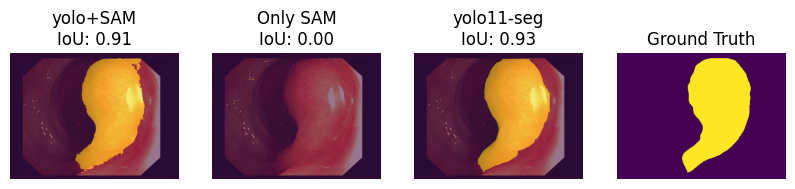


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/398.png: 480x640 1 target, 14.8ms
Speed: 1.9ms preprocess, 14.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/398.png: 480x640 1 target, 15.1ms
Speed: 1.9ms preprocess, 15.1ms inference, 4.4ms postprocess per image at shape (1, 3, 480, 640)


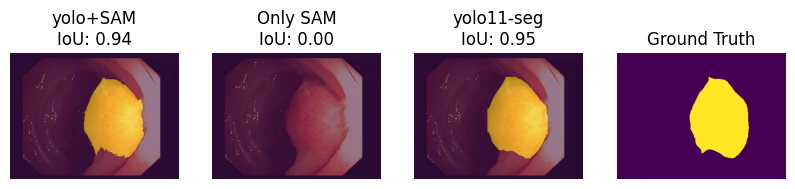


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/400.png: 480x640 1 target, 13.9ms
Speed: 2.5ms preprocess, 13.9ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/400.png: 480x640 1 target, 18.3ms
Speed: 2.2ms preprocess, 18.3ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)


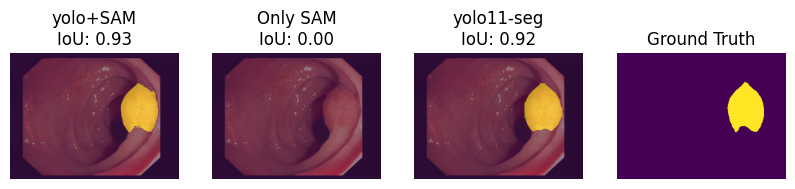


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/411.png: 576x640 2 targets, 13.5ms
Speed: 2.5ms preprocess, 13.5ms inference, 2.0ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/411.png: 576x640 1 target, 16.4ms
Speed: 2.7ms preprocess, 16.4ms inference, 4.2ms postprocess per image at shape (1, 3, 576, 640)


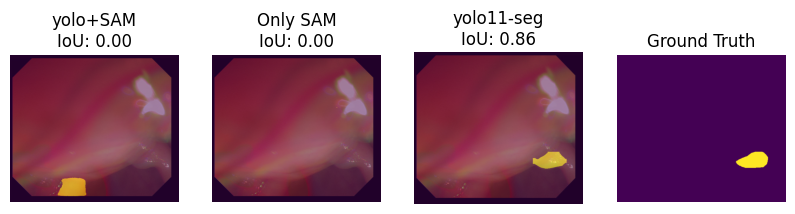


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/422.png: 576x640 1 target, 12.2ms
Speed: 2.3ms preprocess, 12.2ms inference, 1.9ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/422.png: 576x640 1 target, 16.0ms
Speed: 2.3ms preprocess, 16.0ms inference, 4.8ms postprocess per image at shape (1, 3, 576, 640)


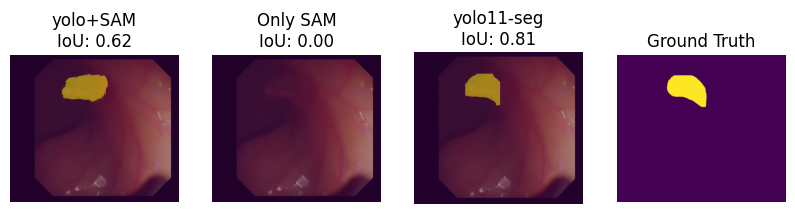


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/428.png: 480x640 1 target, 17.5ms
Speed: 2.4ms preprocess, 17.5ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/428.png: 480x640 1 target, 13.6ms
Speed: 1.9ms preprocess, 13.6ms inference, 3.0ms postprocess per image at shape (1, 3, 480, 640)


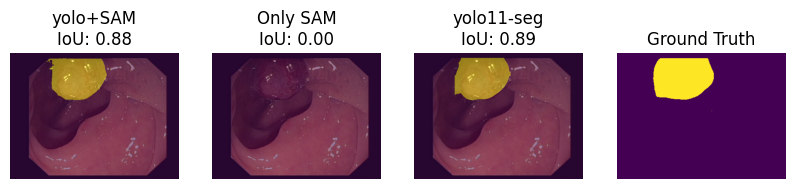


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/429.png: 576x640 1 target, 13.6ms
Speed: 2.5ms preprocess, 13.6ms inference, 3.1ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/429.png: 576x640 1 target, 16.3ms
Speed: 3.8ms preprocess, 16.3ms inference, 4.0ms postprocess per image at shape (1, 3, 576, 640)


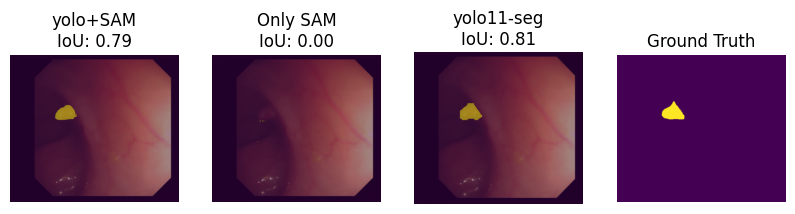


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/434.png: 576x640 1 target, 16.7ms
Speed: 2.4ms preprocess, 16.7ms inference, 2.0ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/434.png: 576x640 1 target, 15.4ms
Speed: 3.0ms preprocess, 15.4ms inference, 3.6ms postprocess per image at shape (1, 3, 576, 640)


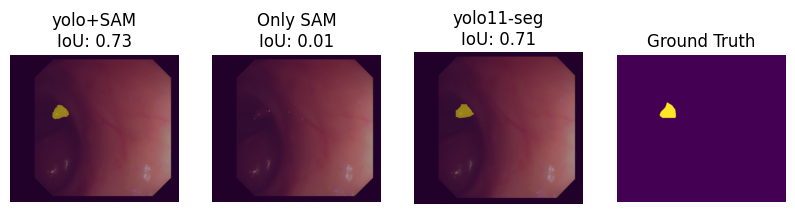


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/440.png: 480x640 1 target, 16.3ms
Speed: 1.9ms preprocess, 16.3ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/440.png: 480x640 2 targets, 16.5ms
Speed: 2.4ms preprocess, 16.5ms inference, 5.2ms postprocess per image at shape (1, 3, 480, 640)


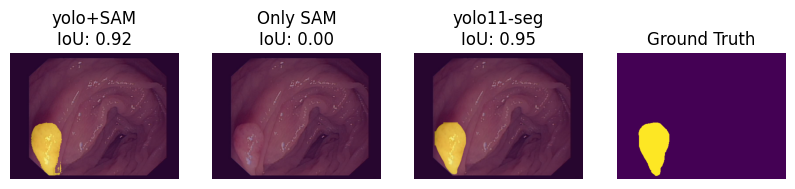


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/451.png: 480x640 1 target, 11.4ms
Speed: 2.0ms preprocess, 11.4ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/451.png: 480x640 1 target, 15.1ms
Speed: 2.7ms preprocess, 15.1ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)


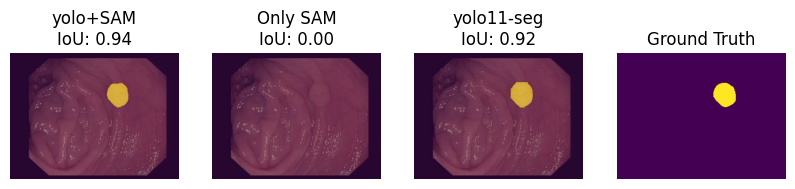


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/461.png: 480x640 1 target, 16.7ms
Speed: 2.7ms preprocess, 16.7ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/461.png: 480x640 1 target, 13.5ms
Speed: 1.8ms preprocess, 13.5ms inference, 3.6ms postprocess per image at shape (1, 3, 480, 640)


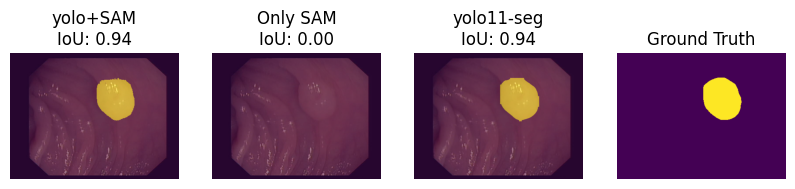


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/465.png: 480x640 1 target, 13.0ms
Speed: 2.0ms preprocess, 13.0ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/465.png: 480x640 1 target, 17.3ms
Speed: 2.0ms preprocess, 17.3ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)


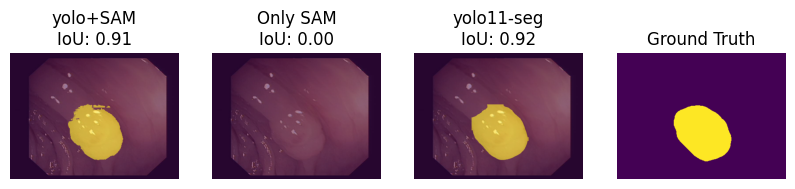


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/470.png: 480x640 1 target, 15.9ms
Speed: 2.0ms preprocess, 15.9ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/470.png: 480x640 1 target, 21.0ms
Speed: 2.0ms preprocess, 21.0ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)


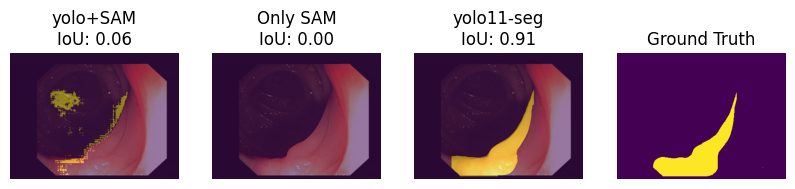


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/483.png: 480x640 1 target, 17.3ms
Speed: 4.2ms preprocess, 17.3ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/483.png: 480x640 1 target, 14.8ms
Speed: 1.8ms preprocess, 14.8ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)


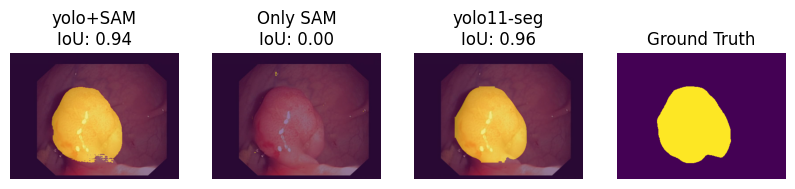


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/50.png: 480x640 1 target, 13.1ms
Speed: 2.0ms preprocess, 13.1ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/50.png: 480x640 1 target, 17.7ms
Speed: 2.0ms preprocess, 17.7ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


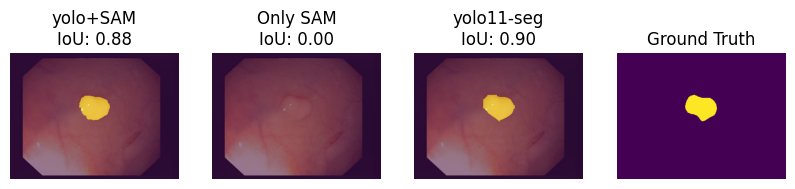


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/506.png: 480x640 1 target, 12.5ms
Speed: 1.9ms preprocess, 12.5ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/506.png: 480x640 1 target, 24.6ms
Speed: 2.2ms preprocess, 24.6ms inference, 3.2ms postprocess per image at shape (1, 3, 480, 640)


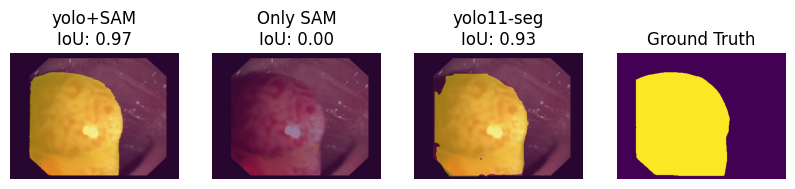


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/510.png: 480x640 1 target, 14.1ms
Speed: 1.9ms preprocess, 14.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/510.png: 480x640 1 target, 12.7ms
Speed: 2.2ms preprocess, 12.7ms inference, 5.3ms postprocess per image at shape (1, 3, 480, 640)


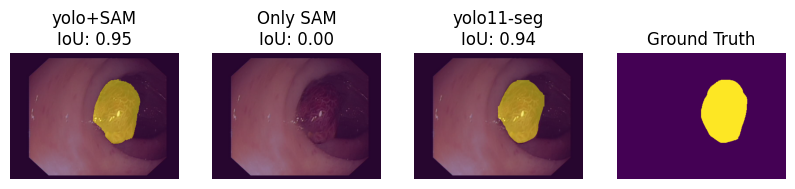


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/516.png: 480x640 1 target, 13.9ms
Speed: 2.8ms preprocess, 13.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/516.png: 480x640 1 target, 17.3ms
Speed: 1.8ms preprocess, 17.3ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)


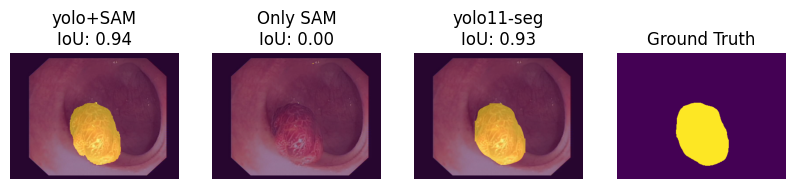


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/527.png: 480x640 1 target, 10.6ms
Speed: 2.0ms preprocess, 10.6ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/527.png: 480x640 1 target, 18.5ms
Speed: 3.1ms preprocess, 18.5ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)


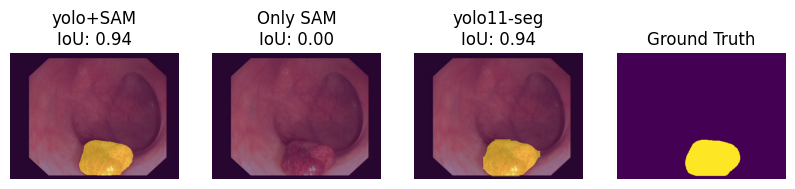


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/534.png: 480x640 1 target, 11.1ms
Speed: 3.0ms preprocess, 11.1ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/534.png: 480x640 1 target, 15.5ms
Speed: 2.1ms preprocess, 15.5ms inference, 3.2ms postprocess per image at shape (1, 3, 480, 640)


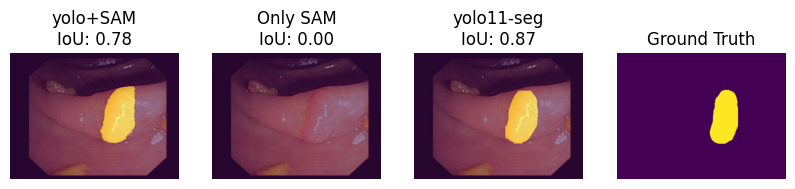


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/546.png: 480x640 1 target, 14.2ms
Speed: 2.1ms preprocess, 14.2ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/546.png: 480x640 1 target, 21.6ms
Speed: 2.3ms preprocess, 21.6ms inference, 7.9ms postprocess per image at shape (1, 3, 480, 640)


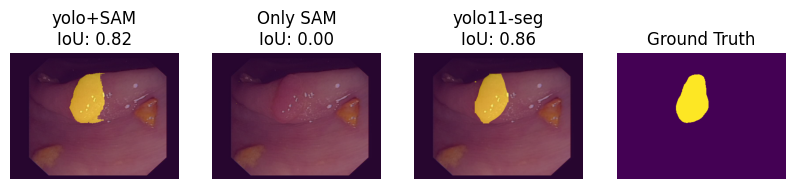


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/555.png: 480x640 2 targets, 15.7ms
Speed: 2.0ms preprocess, 15.7ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/555.png: 480x640 2 targets, 15.0ms
Speed: 2.0ms preprocess, 15.0ms inference, 3.2ms postprocess per image at shape (1, 3, 480, 640)


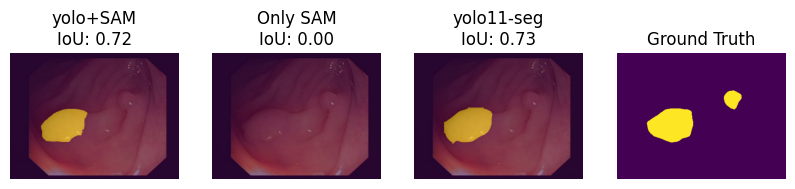


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/56.png: 480x640 1 target, 13.4ms
Speed: 1.9ms preprocess, 13.4ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/56.png: 480x640 1 target, 13.5ms
Speed: 1.9ms preprocess, 13.5ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


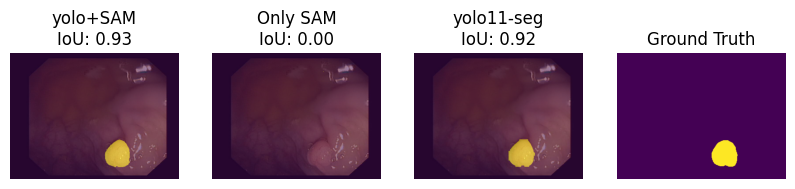


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/562.png: 480x640 2 targets, 14.8ms
Speed: 2.0ms preprocess, 14.8ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/562.png: 480x640 2 targets, 19.8ms
Speed: 2.0ms preprocess, 19.8ms inference, 5.8ms postprocess per image at shape (1, 3, 480, 640)


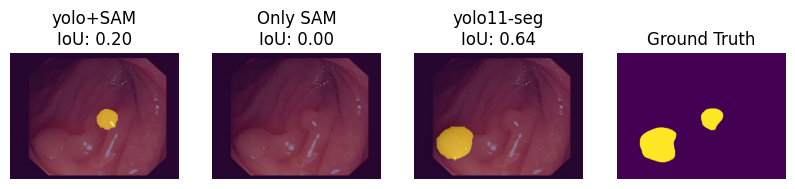


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/576.png: 480x640 1 target, 17.0ms
Speed: 2.4ms preprocess, 17.0ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/576.png: 480x640 1 target, 14.7ms
Speed: 2.0ms preprocess, 14.7ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)


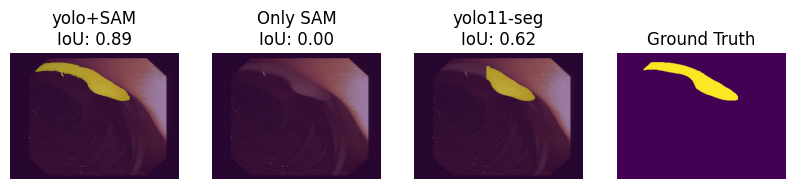


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/591.png: 480x640 1 target, 13.0ms
Speed: 2.0ms preprocess, 13.0ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/591.png: 480x640 1 target, 15.3ms
Speed: 2.3ms preprocess, 15.3ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)


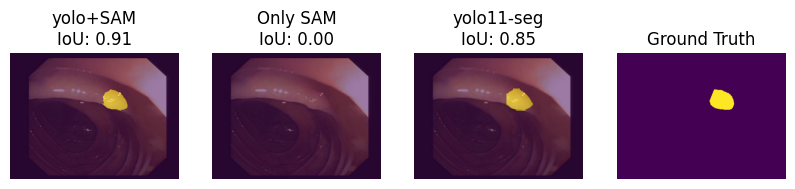


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/610.png: 480x640 2 targets, 12.0ms
Speed: 2.1ms preprocess, 12.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/610.png: 480x640 1 target, 14.6ms
Speed: 2.1ms preprocess, 14.6ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


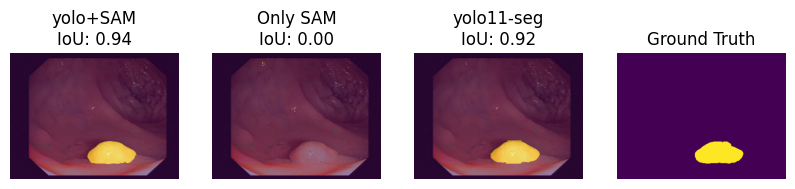


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/63.png: 576x640 1 target, 13.5ms
Speed: 2.5ms preprocess, 13.5ms inference, 9.1ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/63.png: 576x640 1 target, 13.0ms
Speed: 2.8ms preprocess, 13.0ms inference, 3.8ms postprocess per image at shape (1, 3, 576, 640)


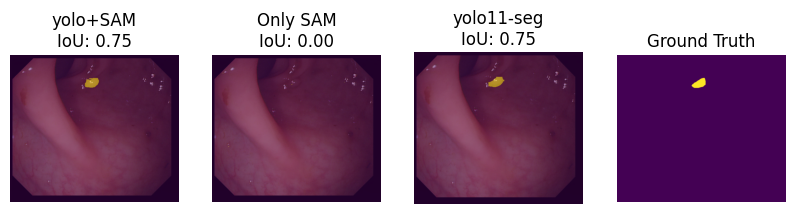


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/64.png: 576x640 1 target, 14.1ms
Speed: 3.1ms preprocess, 14.1ms inference, 3.1ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/64.png: 576x640 1 target, 16.6ms
Speed: 2.6ms preprocess, 16.6ms inference, 5.7ms postprocess per image at shape (1, 3, 576, 640)


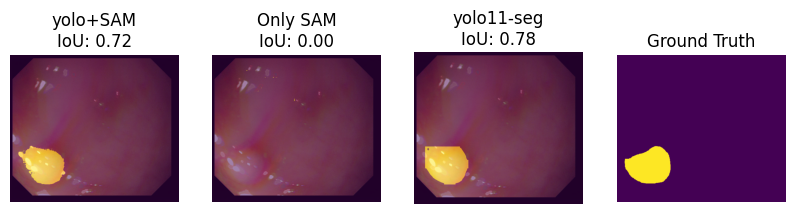


image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/91.png: 576x640 1 target, 16.0ms
Speed: 2.5ms preprocess, 16.0ms inference, 2.4ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /home/stellarlane/main/finetune/sam2/finetune/../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test/91.png: 576x640 1 target, 12.6ms
Speed: 2.4ms preprocess, 12.6ms inference, 3.1ms postprocess per image at shape (1, 3, 576, 640)


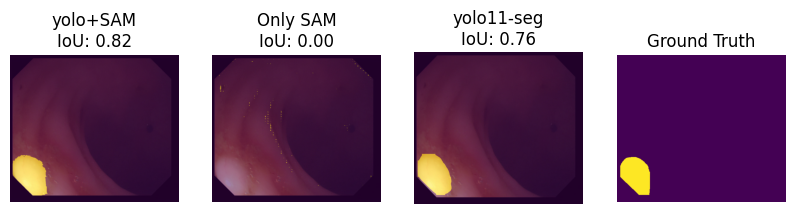

In [32]:
all_images = os.listdir('../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/images/test')
all_images.sort()
all_labels = os.listdir('../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test/masks/test')
all_labels.sort()
IoUs_all = []

for image, label in zip(all_images, all_labels):
    IoUs_all.append(eval_one_pic('../../yolo/datasets/seg_mixed_cli_col_ETIS_with_test', image, label))

In [42]:
import pandas as pd
df = pd.DataFrame(IoUs_all)
df.columns = ['yolo+SAM', 'Only SAM', 'yolo11-seg']

In [43]:
display(df.mean(axis=0))

yolo+SAM      0.842005
Only SAM      0.000281
yolo11-seg    0.871067
dtype: float64